# <font color="#2E86C1"><b>AICE Associate 3회 모의고사</b></font>
---

## <font color="#117A65"><b>교육 플랫폼 사용자 이탈 예측</b></font>

### <font color="#5D6D7E"><b>목적</b></font>  
<b>이탈 가능성이 높은 교육 플랫폼 사용자를 사전에 예측</b>하여  
맞춤형 리텐션 마케팅, 학습 알림 강화 등 자동화된 대응이 가능하도록  
사용자 행동 및 속성 데이터를 기반으로 예측 모델을 구축합니다.

### <font color="#5D6D7E"><b>배경 시나리오</b></font>  

온라인 교육 플랫폼을 운영하는 <b>A사</b>는 최근 사용자 이탈률 증가로  
수강률 및 결제 전환율이 하락하고 있습니다.  
플랫폼을 이용하던 사용자가 일정 기간 이후 더 이상 로그인을 하지 않거나,  
콘텐츠 소비 없이 이탈하는 사례가 증가함에 따라 이를 사전에 예측하고자 합니다.

이에 따라 기업은 실제 이탈 여부 및 사용자 행동, 환경 정보를 포함한  
데이터를 수집하였으며, 아래와 같은 조건을 기반으로  
<b>이탈 여부(`leave_yn`)</b>를 예측하는 모델을 구축하려고 합니다.

---

### 📊 <font color="#5D6D7E"><b>데이터 설명</b></font>  
<b>파일 이름: `edu_users.csv`</b>

| <b>컬럼명</b>             | <b>설명</b>                                                      |
|--------------------------|------------------------------------------------------------------|
| `rate_math`              | 수학 과목 수강 시청률 비율 (%)                                           |
| `rate_science`           | 과학 과목 수강 시청률 비율 (%)                                           |
| `rate_english`           | 영어 과목 수강 시청률 비율 (%)                                           |
| `rate_humanities`        | 인문 과목 수강 시청률 비율 (%)                                           |
| `rate_art`               | 예체능 과목 수강 시청률 비율 (%)                                         |
| `tot_time`               | 총 학습 시간 (분)                                                |
| `device`                 | 접속 기기 (mobile, desktop, tablet 등)                          |
| `gender`                 | 성별 (`M`, `F`)                                                  |
| `age`                    | 연령                                                            |
| `resub_yn`               | 재수강 여부 (`Y`, `N`)                                           |
| `comb_yn`                | 융합 과목 수강 여부 (`Y`, `N`)                                   |
| `othersub_yn`            | 기타 과목 수강 여부 (`Y`, `N`)                                   |
| `leave_yn`               | <mark><b>이탈 여부 (1: 이탈, 0: 유지)</b></mark> ← <b>예측 대상</b> |



### 문제 1. 라이브러리 불러오기

🎯 목표  
데이터 분석을 위해 pandas, numpy, seaborn, matplotlib 라이브러리를 불러옵니다.

📑 조건  
- pandas를 `pd`, numpy를 `np`, seaborn을 `sns`, matplotlib.pyplot을 `plt`로 임포트하세요.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

##### **정답코드**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


### 문제 2. 데이터 파일 불러오기

🎯 목표  
edu_users.csv 파일을 불러와 edu_df 데이터프레임을 생성합니다.

📑 조건
- pandas를 이용하여 파일을 읽고 `edu_df`에 저장하세요.

In [2]:
edu_df = pd.read_csv('datasets/edu_users.csv')

edu_df

,rate_math,rate_science,rate_english,rate_humanities,rate_art,tot_time,device,gender,age,resub_yn,comb_yn,othersub_yn,leave_yn
0,0.375,0.797,0.828,0.896,0.394,17.09,mobile,M,30,N,N,Y,1
1,0.951,0.482,0.765,0.909,0.473,28.57,tablet,F,25,N,Y,N,1
2,0.732,0.117,0.574,0.314,0.855,40.97,tablet,F,24,N,N,N,0
3,0.599,0.125,0.956,0.691,0.340,8.09,mobile,M,14,Y,N,N,1
4,0.156,0.686,0.200,0.272,0.870,45.34,tablet,F,15,Y,N,N,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1245,0.626,0.492,0.212,0.897,0.607,16.80,pc,M,24,Y,N,Y,0
1246,0.131,0.577,0.664,0.119,0.167,33.37,tablet,F,40,N,N,N,0
1247,0.033,0.866,0.411,0.328,0.797,27.37,mobile,M,23,N,N,N,0
1248,0.921,0.981,0.402,0.816,0.720,NaN,pc,F,23,Y,N,Y,0


##### **정답코드**

In [ ]:
edu_df = pd.read_csv('edu_users.csv')


### 문제 3. 데이터프레임 구조 확인

🎯 목표  
데이터의 전체 구조(변수 타입, 결측치 여부 등)를 파악하여 이 정보를 바탕으로 다음 중 **옳지 않은 설명**을 고르세요.

📑 조건  
- edu_df에 대해 .info()를 출력하세요.
- 정답 번호를 `답03` 변수에 저장하세요.

1. `rate_math`, `rate_science`, `tot_time`은 결측치가 존재하며, 모두 실수형(`float64`)이다.  
2. `device`, `gender`, `resub_yn`, `comb_yn`, `othersub_yn`은 범주형 변수이지만, `dtype`은 모두 `object`로 표시된다.  
3. 전체 열은 13개이며, 이 중 수치형(numeric) 변수는 총 8개다.  
4. `leave_yn`은 이탈 여부를 나타내는 이진 분류형 변수이며, 문자형(object)으로 저장되어 있다.

In [3]:
edu_df.info()
답03=1

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rate_math        1188 non-null   float64
 1   rate_science     1188 non-null   float64
 2   rate_english     1250 non-null   float64
 3   rate_humanities  1250 non-null   float64
 4   rate_art         1250 non-null   float64
 5   tot_time         1188 non-null   float64
 6   device           1250 non-null   object 
 7   gender           1250 non-null   object 
 8   age              1250 non-null   int64  
 9   resub_yn         1250 non-null   object 
 10  comb_yn          1250 non-null   object 
 11  othersub_yn      1250 non-null   object 
 12  leave_yn         1250 non-null   int64  
dtypes: float64(6), int64(2), object(5)
memory usage: 127.1+ KB


##### **정답코드**

In [ ]:
edu_df.info()
답03 = 4


### 문제 4. 주요 과목 시청률 상관관계 분석

🖋 상황 설명  
주요 과목 시청률 간의 상관관계를 분석합니다.

🎯 목표
- 아래 셀을 실행하여 corr_list 변수를 생성하세요.


In [4]:
corr_list = ['rate_math', 'rate_science', 'rate_english', 'rate_humanities', 'rate_art']


📑 조건
- corr_list를 활용하여 heatmap을 시각화하고 해석하여, 가장 적절한 설명을 고르세요.
- 정답은 '답04' 변수에 저장하세요
- annot = True
- 소수점은 2째자리까지만 출력

1. `rate_math`와 `rate_science`는 강한 양의 상관관계를 가진다.  
2. `rate_english`와 `rate_humanities`는 -0.5 이상의 음의 상관관계를 가진다.  
3. 전체 과목 간 상관계수는 거의 없으며, 독립적인 경향을 보인다.  
4. `rate_art`와 다른 과목들은 대체로 양의 상관관계를 가진다.

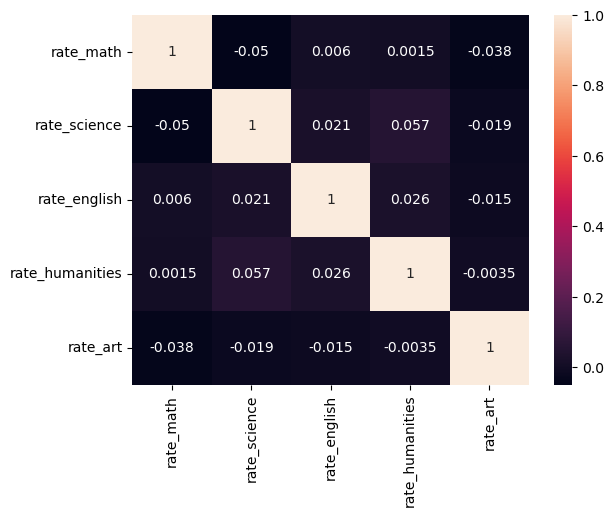

In [5]:
sns.heatmap(
    data=edu_df[corr_list].corr(),          ## heatmap 사용시 data= df['columns',,,].corr() 이거 기억하자.
    annot= True,
    fmt= ".2g"
    )

답04 = 3

##### **정답코드**

In [ ]:
sns.heatmap(data=edu_df[corr_list].corr(),
            annot=True,     
            fmt=".2f")
답04 = 3


### 문제 5. 이탈 여부에 따른 학습 시간 분포 시각화

🎯 목표  
이탈 그룹과 유지 그룹 간 학습 시간 분포를 비교합니다.

📑 조건
- leave_yn 별로 tot_time의 boxplot을 그리고, 이를 바탕으로 다음 보기 중 **올바른 해석**을 고르세요.

1. 유지 사용자(0)는 이탈 사용자(1)보다 평균 학습 시간이 짧고, 이상치가 거의 없다.  
2. 이탈 사용자(1)의 중앙값은 유지 사용자(0)보다 높으며, 전체적인 학습 시간도 길다.  
3. 유지 사용자(0)의 학습 시간 분포가 더 넓고 이상치도 더 많이 존재한다.  
4. 두 그룹 모두 중앙값은 유사하나, 이탈자 쪽이 이상치에 의해 상자 높이가 극단적으로 커졌다.

- 정답은 `답05` 변수에 저장

In [6]:
edu_df.groupby('leave_yn')['tot_time'].describe()       ## describe()로 말문제 대비하자

# 1단게 edu_df.groupby('leave_yn')로 그룹화
# 2단계 ['tot_time'] 그룹화된 데이터에서 tot_time 칼럼 선택
# 3단계 describe() 로 기초통계 출력

,count,mean,std,min,25%,50%,75%,max
leave_yn,,,,,,,,
0,821.0,30.100378,10.215579,1.00,23.380,30.13,37.110,61.13
1,367.0,28.832180,9.669963,4.78,22.275,28.75,34.545,60.98


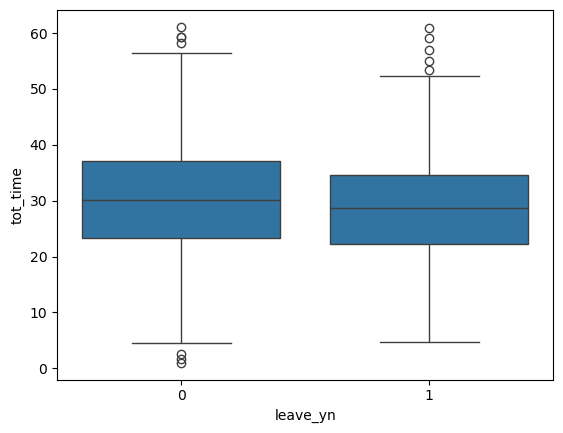

In [7]:
sns.boxplot(data= edu_df, x= 'leave_yn', y= 'tot_time')
답05 = 4

##### **정답코드**

In [ ]:
sns.boxplot(data=edu_df, x='leave_yn', y='tot_time')
답05 = 3
edu_df.groupby('leave_yn')['tot_time'].mean()


### 문제 6. 이탈 여부별 주요 과목 평균 시청률 계산

🎯 목표  
이탈 여부에 따른 과목 시청률 평균을 비교합니다.

📑 조건
- leave_yn 별로 rate_math, rate_science의 평균을 pivot_table()을 이용하여 만드세요.


In [8]:
edu_df.groupby('leave_yn')[['rate_math', 'rate_science']].describe()

rate_math                                                       \
             count      mean       std    min      25%     50%      75%   
leave_yn                                                                  
0            820.0  0.487965  0.292034  0.005  0.23175  0.4950  0.73875   
1            368.0  0.515511  0.295111  0.006  0.25650  0.5365  0.78925   

                rate_science                                                  \
            max        count      mean       std    min    25%    50%    75%   
leave_yn                                                                       
0         0.998        825.0  0.496375  0.293609  0.002  0.238  0.503  0.749   
1         0.997        363.0  0.505424  0.276476  0.006  0.278  0.517  0.724   

                 
            max  
leave_yn         
0         0.999  
1         0.995

In [9]:
## 피벗테이블 만들기.. plt 사용방법과 같다고 보면 됨

edu_pivot = edu_df.pivot_table(
    index='leave_yn',                          # 왼쪽 인덱스
    values= ['rate_math', 'rate_science'],     # 계산대상
    aggfunc='mean'                             # 수행할 계싼
)

edu_pivot

,rate_math,rate_science
leave_yn,,
0,0.487965,0.496375
1,0.515511,0.505424


##### **정답코드**

In [ ]:
pivot_df = edu_df.pivot_table(
    index='leave_yn',
    values=['rate_math', 'rate_science'],
    aggfunc='mean'
)
pivot_df


### 문제 7. 결측치 처리

🎯 목표  
결측치를 적절히 처리하여 데이터 품질을 향상시킵니다.

📑 조건  
- rate_math 컬럼의 결측치를 평균(mean)으로 채우세요.
- rate_science 컬럼의 결측치를 중앙값(median)으로 채우세요. 
- tot_time 컬럼의 결측치를 최빈값(mode)으로 채우세요.


In [10]:
edu_df['rate_math'] = edu_df['rate_math'].fillna(edu_df['rate_math'].mean)
edu_df['rate_science'] = edu_df['rate_science'].fillna(edu_df['rate_science'].median)
edu_df['tot_time'] = edu_df['tot_time'].fillna(edu_df['tot_time'].mode)

# inplace 요구하는 것이 아닌 이상 이렇게 새로 할당하는 방식이 안정적임

##### **정답코드**

In [ ]:
edu_df['rate_math'].fillna(edu_df['rate_math'].mean(), inplace=True)
edu_df['rate_science'].fillna(edu_df['rate_science'].median(), inplace=True)
edu_df['tot_time'].fillna(edu_df['tot_time'].mode()[0], inplace=True)


### 문제 8. train/test 데이터 분리

🎯 목표  
Feature(X)와 Target(y)을 이용하여 모델 학습과 평가를 위해 분리하려고 합니다.

📑 조건  
- Feature: rate_math, rate_science, rate_english, tot_time
- Target: leave_yn
- 데이터셋을 분리하기 위해 train_test_split을 import하세요.
- 훈련 데이터 셋 = X_train, y_train
- 검증 데이터 셋 = X_valid, y_valid
- random_state=42
- 훈련 데이터셋과 검증 데이터셋의 비율은 8:2


In [ ]:
X = edu_df[['rate_math', 'rate_science', 'rate_english', 'tot_time']]
y = edu_df['leave_yn']

from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size= 0.2, random_state=42)


##### **정답코드**

In [ ]:
Feature = edu_df[['rate_math', 'rate_science', 'rate_english', 'tot_time']]
Target = edu_df['leave_yn']

from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(Feature, Target, test_size=0.2, random_state=42)

In [14]:
# 1. 처음부터 다시 시작 - 데이터 다시 로드
edu_df = pd.read_csv('datasets/edu_users.csv')

# 2. 데이터 확인
print(edu_df.head())
print(edu_df.dtypes)
print(edu_df.info())

# 3. Feature와 Target 정확히 분리
X = edu_df[['rate_math', 'rate_science', 'rate_english', 'tot_time']].copy()
y = edu_df['leave_yn'].copy()

# 4. X의 데이터 타입 확인 및 변환
print("\n=== X 데이터 타입 ===")
print(X.dtypes)

# 숫자형으로 강제 변환
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# 결측치 확인 및 처리
print("\n=== 결측치 확인 ===")
print(X.isnull().sum())
X = X.fillna(X.mean())

# 5. 이제 train/test 분리
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. 스케일링
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

print("\n=== 성공! ===")
print(f"X_train_scaled 형태: {X_train_scaled.shape}")
print(f"X_valid_scaled 형태: {X_valid_scaled.shape}")

   rate_math  rate_science  rate_english  rate_humanities  rate_art  tot_time  \
0      0.375         0.797         0.828            0.896     0.394     17.09   
1      0.951         0.482         0.765            0.909     0.473     28.57   
2      0.732         0.117         0.574            0.314     0.855     40.97   
3      0.599         0.125         0.956            0.691     0.340      8.09   
4      0.156         0.686         0.200            0.272     0.870     45.34   

   device gender  age resub_yn comb_yn othersub_yn  leave_yn  
0  mobile      M   30        N       N           Y         1  
1  tablet      F   25        N       Y           N         1  
2  tablet      F   24        N       N           N         0  
3  mobile      M   14        Y       N           N         1  
4  tablet      F   15        Y       N           N         0  
rate_math          float64
rate_science       float64
rate_english       float64
rate_humanities    float64
rate_art           float64



### 문제 9. Feature 스케일링

🎯 목표  
데이터 스케일링을 통해 모델 학습의 성능을 높입니다.

[사전 실행 지시사항]
- 아래 셀을 실행하여 StandardScaler를 불러오세요.


📑 조건  
- StandardScaler를 이용해 Feature 데이터를 스케일링하세요.
- X_train은 fit_tranform을 이용하여 X_train 변수에 저장
- X_valid는 transform을 이용하여 X_test의 변수에 저장


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_valid)

##### **정답코드**

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_valid)


### 문제 10. 랜덤포레스트 모델 학습

🎯 목표  
랜덤포레스트 모델을 활용하여 이탈 여부를 예측합니다.

[사전 실행 지시사항]
- 아래 셀을 실행하여 RandomForestClassifier를 불러오세요.



📑 조건  
- RandomForestClassifier를 사용해 leave_yn을 예측하는 모델을 학습하세요.
- 랜덤포레스트모델을 rfc변수에 저장하세요.
- n_estimators=150, max_depth=7, min_samples_split=5, random_state=42
- 훈련은 스케일링 처리된 데이터를 사용해 주세요.



In [16]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(
    n_estimators=150,
    max_depth=7,
    min_samples_split= 5,
    random_state=42
)

rfc.fit(X_train, y_train)

RandomForestClassifier(max_depth=7, min_samples_split=5, n_estimators=150,
                       random_state=42)

##### **정답코드**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=150, max_depth=7, min_samples_split=5, random_state=42)

rfc.fit(X_train,y_train)


### 문제 11. XGBoost 모델 학습

🎯 목표  
XGBoost를 활용하여 이탈 여부를 예측합니다.

[사전 실행 지시사항]
- 아래 셀을 실행하여 XGBClassifier를 불러오세요.


In [17]:
from xgboost import XGBClassifier


📑 조건  
- XGBClassifier를 사용해 leave_yn을 예측하는 모델을 학습하세요.
- XGBoost모델을 xgbc변수에 저장하세요.
- n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42
- 훈련은 스케일링 처리된 데이터를 사용하여 주세요.


In [19]:
xgbc = XGBClassifier(
    n_estimators= 200,
    max_depth = 5,
    learning_rate= 0.1,
    random_state=42
)

xgbc.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

##### **정답코드**

In [ ]:
from xgboost import XGBClassifier

xgbc = XGBClassifier(n_estimators = 200, max_depth = 5, learning_rate = 0.1, random_state = 42)
xgbc.fit(X_train, y_train)


### 문제 12. 모델 성능 평가

🎯 목표  
학습된 모델의 정확도와 F1 점수를 비교합니다.

📑 조건  
- randomforest의 predict를 이용하여 검증 데이터를 예측하고, 예측된 데이터는 rfc_predict변수에 저장하여 주세요.
- xgboost의 predict를 이용하여 검증 데이터를 예측하고, 예측된 데이터는 xgbc_predict변수에 저장하여 주세요.
- accuracy_score와 f1_score를 사용하여 두 모델의 성능을 비교하고, 정확도가 더 높은 모델을 답12 변수에 저장하세요.(예 : 답12 = 'RF' or 'XGBC')  


In [ ]:
from  sklearn.metrics import accuracy_score, f1_score           ## 평가지표는 sklearn.metrics 기억하자!!

rfc_predict = rfc.predict(X_test)
xgbc_predict= xgbc.predict(X_test)

print(accuracy_score(rfc_predict, y_valid), f1_score(rfc_predict, y_valid))
print(accuracy_score(xgbc_predict, y_valid), f1_score(xgbc_predict, y_valid))

답12 = 'RF'

0.632 0.02127659574468085
0.612 0.24806201550387597


##### **정답코드**

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

rfc_predict = rfc.predict(X_valid)
xgbc_predict = xgbc.predict(X_valid)

print("Random Forest")
print("Accuracy:", accuracy_score(y_valid, rfc_predict))
print("F1 Score:", f1_score(y_valid, rfc_predict))

print("XGBoost")
print("Accuracy:", accuracy_score(y_valid, xgbc_predict))
print("F1 Score:", f1_score(y_valid, xgbc_predict))

답12 = 'XGBC'


### 문제 13. 딥러닝 분류 모델 설계 및 학습

🎯 목표  
딥러닝 모델을 구성하여 이탈 여부를 예측합니다.

[사전 실행 지시사항]
- 아래 셀을 실행하여 TensorFlow 라이브러리를 불러오세요.


In [21]:
import tensorflow as tf                     ## 외워가라..
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
tf.random.set_seed(10)


📑 조건  
- 다음을 보고 모델을 구성하고 학습하세요.
  
  ##### **모델 구조**
  - Dense(64, selu) → BatchNormalization  
  - Dense(32, selu) → BatchNormalization  
  - Dense(16, selu)  
  - Dense(1, sigmoid)
  
  ##### **학습 설정**

  - Optimizer: adam  
  - Loss: binary_crossentropy  
  - Metric: accuracy  
  - Epochs: 45  
  - Batch size: 32  


In [25]:
model = Sequential()
model.add(Dense(64, activation= 'selu', input_shape=(X_train.shape[1], ) ))         ## input_shape = (X_train.shape[1], ) 이거 자꾸 까먹더라
model.add(BatchNormalization())
model.add(Dense(32, activation= 'selu'))
model.add(BatchNormalization())
model.add(Dense(16, activation= 'selu'))
model.add(Dense(1, activation= 'sigmoid'))

model.compile(
    optimizer='adam',
    loss = 'binary_crossentropy',
    metrics= ['accuracy']
)

model.fit(
    X_train, y_train,
    epochs=45,
    batch_size=32,
    validation_data = (X_test, y_valid)
)

Epoch 1/45


c:\Users\16Z90P\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6060 - loss: 0.6854 - val_accuracy: 0.4880 - val_loss: 0.6839
Epoch 2/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6850 - loss: 0.6263 - val_accuracy: 0.6560 - val_loss: 0.6599
Epoch 3/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6940 - loss: 0.6162 - val_accuracy: 0.6600 - val_loss: 0.6543
Epoch 4/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6960 - loss: 0.6110 - val_accuracy: 0.6640 - val_loss: 0.6528
Epoch 5/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6950 - loss: 0.6073 - val_accuracy: 0.6560 - val_loss: 0.6549
Epoch 6/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6960 - loss: 0.6035 - val_accuracy: 0.6560 - val_loss: 0.6572
Epoch 7/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6970 - loss: 0.6010 - val_accuracy: 0.6560 - val_loss: 0.6594
Epoch 8/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6950 - loss: 0.5990 - val_accuracy: 0.6600 - val_loss: 0.6634
Ep

##### **정답코드**

In [ ]:
model = Sequential()
model.add(Dense(64, activation='selu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dense(32, activation='selu'))
model.add(BatchNormalization())
model.add(Dense(16, activation='selu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train, y_train,
    epochs=45,
    batch_size=32
)


### 문제 14. 딥러닝 모델을 이용한 시뮬레이션 예측

🖋 상황 설명   
딥러닝 모델을 이용해 새로운 데이터를 예측합니다.

[사전 실행 지시사항]
- 아래 셀을 실행하여 시뮬레이션 데이터를 생성하세요.


In [24]:
simul_data = np.array([[0.3, 0.5, 0.7, 120]])


📑 조건  
- simul_data를 이용해 예측 결과를 출력하고 해당 결과를 deep_pre 변수로 저장하세요.
- 저장된 데이터는 sigmoid로 인해 확률 값을 나타내고 있습니다.
  - 0.5를 기준으로 미만이면 0, 이상이면 1로 저장하는 코드를 작성하고 해당 값을 '답14' 변수에 저장하세요.
  - numpy의 where을 사용하여 처리하세요.


In [ ]:
deep_pre = model.predict(simul_data)

np.where(deep_pre >= 0.5, 1, 0)

deep_pre

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


array([[0.]], dtype=float32)

##### **정답코드**

In [ ]:
deep_pre = model.predict(simul_data)

답14 = np.where(deep_pre >= 0.5, 1, 0)